In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import nltk.corpus
import nltk.tokenize
import re
import pymorphy3
from pymystem3 import Mystem
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay


## Морфологические признаки с использованием библиотеки pymorphy3.

In [2]:
morph = pymorphy3.MorphAnalyzer()

функция для вычисления частот частей речи

In [ ]:
def extract_pos_features(text):
    words = str(text).split()
    pos_counts = {}
    total_words = len(words)
    
    for word in words:
        parsed = morph.parse(word)[0]
        pos = parsed.tag.POS
        if pos:
            pos_counts[pos] = pos_counts.get(pos, 0) + 1
    
    pos_features = {f'pos_{k}': v/total_words for k, v in pos_counts.items()}
    return pos_features

In [4]:
negative_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\negative.csv'
positive_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\positive.csv'

In [5]:
#считываем файл
negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)

In [6]:
sentiment = pd.concat([negative_df, positive_df])[['id','ttext', 'ttype']]

In [7]:
sentiment.loc[(sentiment.ttype < 0), ('ttype')] = 0
sentiment

,id,ttext,ttype
0,408906762813579264,на работе был полный пиддес :| и так каждое за...,0
1,408906818262687744,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,408906858515398656,@elina_4post как говорят обещаного три года жд...,0
3,408906914437685248,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,408906914723295232,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...,...
9995,409208735219736576,"Все равно, я бы чувствовала себя лучше, если б...",1
9996,409208736738476032,-Я пошла вешаться...-Что?! Что случилось?-Проб...,1
9997,409208736885248000,"Идеальный перерыв с любимой Катюхой, пиано мас...",1
9998,409208737015283712,Удахгүй дүн гарахаар мэдээлэл хийнээ :)) http:...,1


In [8]:
freq_df = sentiment['ttext'].apply(extract_pos_features).apply(pd.Series)

freq_df = freq_df.fillna(0)
freq_df.columns = ['pos_' + str(col) for col in freq_df.columns]

sentiment_with_features = pd.concat([
    sentiment[['id', 'ttext', 'ttype']], 
    freq_df
], axis=1)

sentiment_with_features.to_csv('morphological_features.csv', index=False, encoding='utf-8')

In [9]:
morphological_features_path = 'C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\morphological_features.csv'

In [31]:
morphological_features = pd.read_csv(morphological_features_path, delimiter=",")

In [40]:
morphological_features.head(3)

,id,ttext,ttype,pos_pos_PREP,pos_pos_NOUN,pos_pos_VERB,pos_pos_ADJF,pos_pos_CONJ,pos_pos_NPRO,pos_pos_PRCL,pos_pos_PRTF,pos_pos_NUMR,pos_pos_GRND,pos_pos_ADVB,pos_pos_INFN,pos_pos_INTJ,pos_pos_PRED,pos_pos_ADJS,pos_pos_COMP,pos_pos_PRTS
0,408906762813579264,на работе был полный пиддес :| и так каждое за...,0,0.062500,0.187500,0.125000,0.125000,0.187500,0.062500,0.062500,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,408906818262687744,"Коллеги сидят рубятся в Urban terror, а я из-з...",0,0.142857,0.142857,0.214286,0.000000,0.071429,0.071429,0.071429,0.071429,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,408906858515398656,@elina_4post как говорят обещаного три года жд...,0,0.000000,0.142857,0.142857,0.142857,0.142857,0.000000,0.000000,0.000000,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
X = morphological_features.drop(['id','ttype', 'ttext'], axis=1)
y=sentiment['ttype'].values.tolist()

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [35]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
def plot_confusion(model_name, y_pred, y_test):
   
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    
    # Подписи классов
    labels = ["Отрицательный", "Положительный"]
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Предсказанные метки")
    plt.ylabel("Истинные метки")
    plt.title(f"Матрица ошибок ({model_name})")
    plt.show()

In [37]:
# Создание и обучение модели
svc = SVC(random_state=42, kernel='rbf')
svc.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



Classification report:

               precision    recall  f1-score   support

           0       0.58      0.56      0.57      2990
           1       0.57      0.59      0.58      3010

    accuracy                           0.58      6000
   macro avg       0.58      0.58      0.58      6000
weighted avg       0.58      0.58      0.58      6000



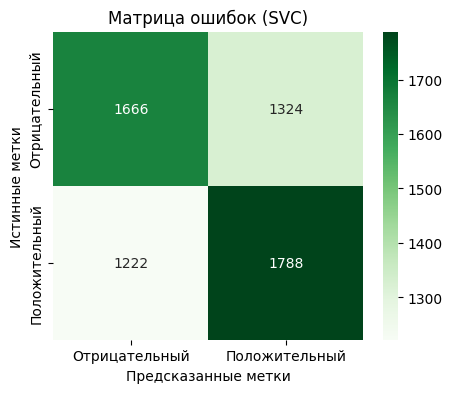

In [38]:
# Предсказания
y_pred_svc = svc.predict(X_test_scaled)

# Метрики

acc = accuracy_score(y_test, y_pred_svc)

print("\nClassification report:\n\n", classification_report(y_test, y_pred_svc))
plot_confusion("SVC", y_pred_svc, y_test)

In [10]:
def add_pos_tags(text):

    words = str(text).split()
    tagged_words = []
    
    for word in words:
        parsed = morph.parse(word)[0]
        tag = parsed.tag.POS or 'X'
        lemma = parsed.normal_form
        tagged_words.append(f"{lemma}_{tag}")
    
    return ' '.join(tagged_words)

# Применяем
sentiment['text_pos'] = sentiment['ttext'].apply(add_pos_tags)

In [11]:
sentiment.head()

,id,ttext,ttype,text_pos
0,408906762813579264,на работе был полный пиддес :| и так каждое за...,0,на_PREP работа_NOUN быть_VERB полный_ADJF пидд...
1,408906818262687744,"Коллеги сидят рубятся в Urban terror, а я из-з...",0,коллега_NOUN сидеть_VERB рубиться_VERB в_PREP ...
2,408906858515398656,@elina_4post как говорят обещаного три года жд...,0,@elina_4post_X как_CONJ говорить_VERB обещаной...
3,408906914437685248,"Желаю хорошего полёта и удачной посадки,я буду...",0,желать_VERB хороший_ADJF полёт_NOUN и_CONJ уда...
4,408906914723295232,"Обновил за каким-то лешим surf, теперь не рабо...",0,обновить_VERB за_PREP какой-то_ADJF леший_NOUN...


In [13]:
sentiment.to_csv('sentiment_POS.csv', index=False, encoding='utf-8')

## TF-IDF признаки

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = sentiment['ttext'].values

nltk.download('stopwords')
russian_stopwords = set(stopwords.words('russian'))
words_to_exclude = {'лучше', 'хорошо'}
final_stopwords = list(russian_stopwords - words_to_exclude)

# TF-IDF векторайзер
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    lowercase=True,
    strip_accents='unicode',  
    stop_words=final_stopwords,          # стоп-слова не удаляем (или можно добавить 'russian')
    token_pattern=r'(?u)\b[а-яА-Яa-zA-Z][а-яА-Яa-zA-Z]+\b'  # только слова из букв
)

X_tfidf = tfidf_vectorizer.fit_transform(texts)

feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=feature_names
)
tfidf_df.insert(0, 'id', sentiment['id'].values)
tfidf_df.insert(1, 'ttype', sentiment['ttype'].values)
tfidf_df.insert(2, 'ttext', sentiment['ttext'].values)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Landi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Landi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['другои', 'еи', 'какои', 'мои', 'неи', 'сеичас', 'такои', 'этои'] not in stop_words.
  warnings.warn(


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = sentiment['ttext'].values

nltk.download('stopwords')
russian_stopwords = set(stopwords.words('russian'))
words_to_exclude = {'лучше', 'хорошо'}
final_stopwords = list(russian_stopwords - words_to_exclude)

# TF-IDF векторайзер
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    lowercase=True,
    strip_accents='unicode',  
    stop_words=final_stopwords,
    token_pattern=r'(?u)\b[а-яА-Я][а-яА-Я]+\b'  # только слова из букв
)

X_tfidf = tfidf_vectorizer.fit_transform(texts)

feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=feature_names
)
tfidf_df.insert(0, 'id', sentiment['id'].values)
tfidf_df.insert(1, 'ttype', sentiment['ttype'].values)
tfidf_df.insert(2, 'ttext', sentiment['ttext'].values)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Landi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Landi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['другои', 'еи', 'какои', 'мои', 'неи', 'сеичас', 'такои', 'этои'] not in stop_words.
  warnings.warn(


In [27]:
tfidf_df

,id,ttype,ttext,ааа,аааа,ааааа,ага,аж,ах,ахах,...,этим,этих,это,это круто,это очень,это просто,этои,этому,эх,явно
0,408906762813579264,0,на работе был полный пиддес :| и так каждое за...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,408906818262687744,0,"Коллеги сидят рубятся в Urban terror, а я из-з...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,408906858515398656,0,@elina_4post как говорят обещаного три года жд...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,408906914437685248,0,"Желаю хорошего полёта и удачной посадки,я буду...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,408906914723295232,0,"Обновил за каким-то лешим surf, теперь не рабо...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,409208735219736576,1,"Все равно, я бы чувствовала себя лучше, если б...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19996,409208736738476032,1,-Я пошла вешаться...-Что?! Что случилось?-Проб...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19997,409208736885248000,1,"Идеальный перерыв с любимой Катюхой, пиано мас...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19998,409208737015283712,1,Удахгүй дүн гарахаар мэдээлэл хийнээ :)) http:...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
tfidf_df.shape

(20000, 1003)

In [29]:
tfidf_df.to_csv('tfidf_features.csv', index=False, encoding='utf-8')

In [30]:
X_tfidf = tfidf_df.drop(['id','ttype', 'ttext'], axis=1)
y_tfidf=sentiment['ttype'].values.tolist()

In [31]:
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(X_tfidf, y_tfidf, test_size=0.3, random_state=0)

In [32]:
# Масштабирование
scaler = StandardScaler()
X_tfidf_train_scaled = scaler.fit_transform(X_tfidf_train)
X_tfidf_test_scaled = scaler.transform(X_tfidf_test)

In [33]:
# Создание и обучение модели
svc = SVC(random_state=42, kernel='rbf')
svc.fit(X_tfidf_train_scaled, y_tfidf_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



Classification report:

               precision    recall  f1-score   support

           0       0.65      0.55      0.60      2990
           1       0.61      0.71      0.66      3010

    accuracy                           0.63      6000
   macro avg       0.63      0.63      0.63      6000
weighted avg       0.63      0.63      0.63      6000



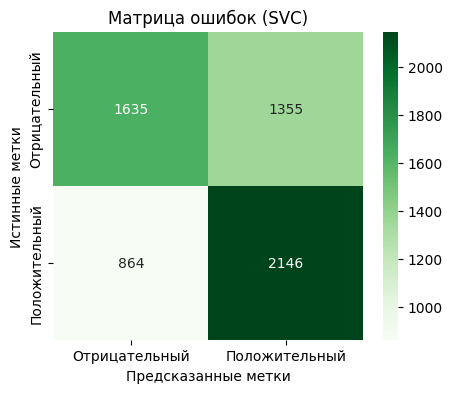

In [37]:
# Предсказания
y_tfidf_pred_svc = svc.predict(X_tfidf_test_scaled)

# Метрики

acc = accuracy_score(y_tfidf_test, y_tfidf_pred_svc)

print("\nClassification report:\n\n", classification_report(y_tfidf_test, y_tfidf_pred_svc))
plot_confusion("SVC", y_tfidf_pred_svc, y_tfidf_test)